In [1]:
#Import necessary libraries and such for project. And some extra stuff, just in case.
import pandas as pd
import matplotlib
from pandas import DataFrame
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import datetime
import seaborn as sns

In [74]:
#read in housing data 
filtered_cf = pd.read_csv('filtered_cf.csv')
average_ppsf = pd.read_csv('average_ppsf.csv')
average_saleprice = pd.read_csv('average_saleprice.csv')

In [79]:
filtered_cf

,Unnamed: 0,Period Begin,Period End,Region,Property Type,Median Sale Price,Median List Price,Median Ppsf
0,68,2025-01-01,2025-01-31,"Clark County, IN",Single Family Residential,250000.0,274900.0,145.509943
1,70,2025-01-01,2025-01-31,"Floyd County, IN",Single Family Residential,253900.0,290000.0,137.500000
2,141,2024-10-01,2024-10-31,"Floyd County, IN",Single Family Residential,235000.0,274900.0,155.259823
3,209,2024-11-01,2024-11-30,"Clark County, IN",Single Family Residential,260000.0,244900.0,171.232980
4,212,2024-11-01,2024-11-30,"Floyd County, IN",Single Family Residential,286500.0,269000.0,154.476351
5,281,2024-12-01,2024-12-31,"Clark County, IN",Single Family Residential,234945.0,262990.0,155.327776
6,285,2024-12-01,2024-12-31,"Floyd County, IN",Single Family Residential,301750.0,252450.0,148.990538
7,349,2024-02-01,2024-02-29,"Clark County, IN",Single Family Residential,252000.0,248500.0,160.736976
8,353,2024-02-01,2024-02-29,"Floyd County, IN",Single Family Residential,275000.0,302400.0,148.026316
9,415,2024-03-01,2024-03-31,"Clark County, IN",Single Family Residential,250000.0,263500.0,165.925455


In [82]:
plt.figure(figsize=(10, 6))
filtered = filtered_cf.groupby('Region')['Median Sale Price']


# Highlight the highest value in blue, others in light grey
# colors = [

plt.bar(filtered.index, filtered.values, color=colors)

# Add value only on the blue bar (the highest one)
plt.text(0, filtered.values[0], f'{filtered.values[0]:,.0f}', 
         ha='center', va='bottom', fontsize=12, color='black')

# Formatting for x-axis labels and title
plt.xticks(rotation=45, ha='right')
plt.title('Median Sale Prices in Southern Indiana from Feb. 2024 - Jan. 2025')
plt.xlabel('Median Sale Price ($)')
plt.ylabel('County')

# Add comma formatting for y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# 2. Top 10 Categories by Number of Backers
plt.figure(figsize=(10, 6))
filtered = filtered_cf.groupby('Region')['Median Sale Price']

# Highlight the highest value in blue, others in light grey
# colors = ['blue' if i == 0 else 'lightgrey' for i in range(len(top_backers))]

plt.bar(filtered.index, filtered.values, color=colors)

# Add value only on the blue bar (the highest one)
plt.text(0, top_backers.values[0], f'{top_backers.values[0]:,.0f}', 
         ha='center', va='bottom', fontsize=12, color='black')

# Formatting for x-axis labels and title
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Categories by Number of Backers')
plt.xlabel('Category')
plt.ylabel('Number of Backers')

# Add comma formatting for y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


AttributeError: 'SeriesGroupBy' object has no attribute 'index'

<Figure size 1000x600 with 0 Axes>

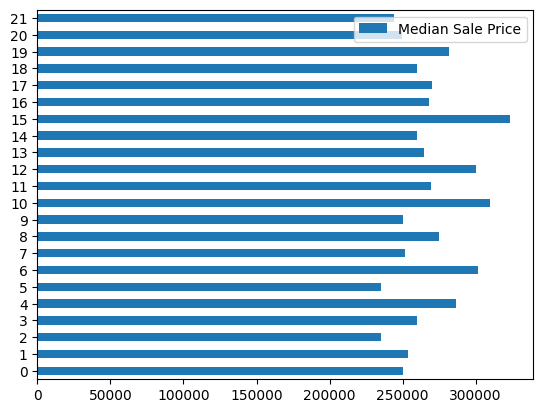

In [ ]:
#
# ax = filtered_cf.plot.barh(y='Median Sale Price')

In [77]:
# Create a bar graph comparing median home sale prices for two counties from 2/2024 to 1/2025
fig = px.bar(filtered_cf, x='Median Sale Price', y='Period Begin', color='Region', orientation='h', barmode='group',
             title='Median Sale Prices for the last rolling 12 months',
             labels={'Median Sale Price': 'Median Home Price ($)', 'Date': 'Period Begin'},
             height=400)

fig.show()

In [4]:
# Create a bar graph to display average home sale prices
fig = px.bar(average_saleprice, x='Median Sale Price', y='Region', color='Region', barmode='group',
             title='Average Home Sale Price February 2024 - January 2025',
             labels={'Median Sale Price': 'Median Home Price ($)', 'Region': 'County'},
             height=400)

fig.show()

In [5]:
# Create a bar graph to display average ppsf
fig = px.bar(average_ppsf, x='Median Ppsf', y='Region', color='Region', barmode='group',
             title='Average of Median Price per Square Foot from February 2024 - January 2025 in Southern Indiana',
             labels={'Median Sale Price': 'Median Price per Square Foot Average ($)', 'Region': 'County'},
             height=400)

fig.show()

In [50]:
#read in ilearn data 
ilearnG3df = pd.read_csv('ilearnG3df.csv')
soc_copy3 = pd.read_csv('soc_copy3.csv')
t_ilearnG3 = pd.read_csv('t_ilearnG3.csv')

In [60]:
ilearnG3df

,Corporation Name,Corp ID,ELA Proficient %,Math Proficient %,Science Proficient %
0,Borden-Henryville School Corporation,935,30.9%,49.1%,49.6%
1,Silver Creek School Corporation,945,41.7%,54.8%,41.5%
2,Clarksville Community School Corp,1000,13.7%,25.1%,20.6%
3,Greater Clark County Schools,1010,35.3%,47.1%,37.6%
4,New Albany-Floyd Co Con Sch,2400,55.8%,71.1%,49.1%


In [61]:
ilearn_copy = ilearnG3df.copy()


In [63]:
ilearn_copy['ELA Proficient %'] = ilearn_copy['ELA Proficient %'].str.rstrip('%').astype('float') / 100.0
ilearn_copy

,Corporation Name,Corp ID,ELA Proficient %,Math Proficient %,Science Proficient %
0,Borden-Henryville School Corporation,935,0.309,49.1%,49.6%
1,Silver Creek School Corporation,945,0.417,54.8%,41.5%
2,Clarksville Community School Corp,1000,0.137,25.1%,20.6%
3,Greater Clark County Schools,1010,0.353,47.1%,37.6%
4,New Albany-Floyd Co Con Sch,2400,0.558,71.1%,49.1%


In [64]:
ilearn_copy['Math Proficient %'] = ilearn_copy['Math Proficient %'].str.rstrip('%').astype('float') / 100.0
ilearn_copy

,Corporation Name,Corp ID,ELA Proficient %,Math Proficient %,Science Proficient %
0,Borden-Henryville School Corporation,935,0.309,0.491,49.6%
1,Silver Creek School Corporation,945,0.417,0.548,41.5%
2,Clarksville Community School Corp,1000,0.137,0.251,20.6%
3,Greater Clark County Schools,1010,0.353,0.471,37.6%
4,New Albany-Floyd Co Con Sch,2400,0.558,0.711,49.1%


In [65]:
ilearn_copy['Science Proficient %'] = ilearn_copy['Science Proficient %'].str.rstrip('%').astype('float') / 100.0
ilearn_copy

,Corporation Name,Corp ID,ELA Proficient %,Math Proficient %,Science Proficient %
0,Borden-Henryville School Corporation,935,0.309,0.491,0.496
1,Silver Creek School Corporation,945,0.417,0.548,0.415
2,Clarksville Community School Corp,1000,0.137,0.251,0.206
3,Greater Clark County Schools,1010,0.353,0.471,0.376
4,New Albany-Floyd Co Con Sch,2400,0.558,0.711,0.491


In [66]:
ilearn_copy

,Corporation Name,Corp ID,ELA Proficient %,Math Proficient %,Science Proficient %
0,Borden-Henryville School Corporation,935,0.309,0.491,0.496
1,Silver Creek School Corporation,945,0.417,0.548,0.415
2,Clarksville Community School Corp,1000,0.137,0.251,0.206
3,Greater Clark County Schools,1010,0.353,0.471,0.376
4,New Albany-Floyd Co Con Sch,2400,0.558,0.711,0.491


<Axes: >

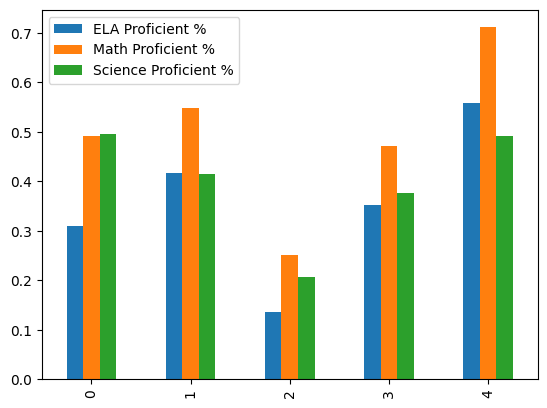

In [73]:
pleasework = ilearn_copy.drop(columns="Corp ID")

pleasework.plot.bar()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

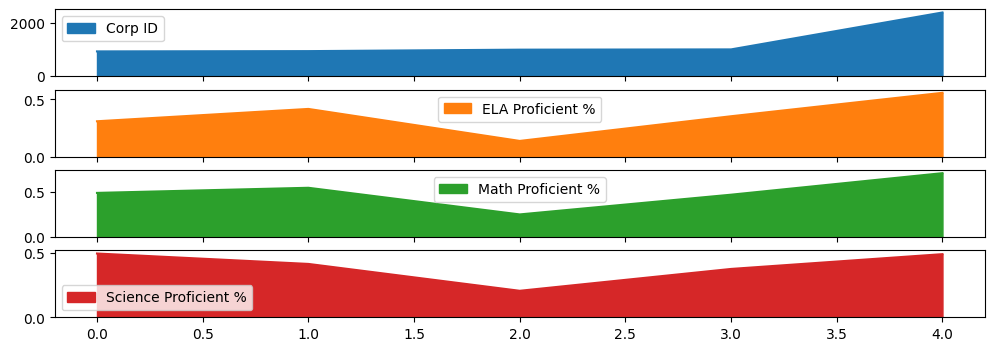

In [67]:
finwork = ilearn_copy.plot.area(figsize=(12, 4), subplots=True)

finwork.plot(Xlabel="New X", ylabel="New Y")
plt.show()

In [36]:
# Limit Genre_1 to the top 5 counts
G3Prof = ilearnG3df["Corporation Name"] # .value_counts().head(5).index

# Filter the original DataFrame to include only the top 5 values
#genre1_top5 = ilearnG3df[ilearnG3df[""].isin()]

# Group by Genre_1 and count the number of each genre by Service Name
#genre_counts = genre1_top5.groupby("Genre_1")["Service_Name"].value_counts().unstack()

# Sort the values in the DataFrame before plotting
G3Prof = G3Prof.sort_index(axis=1, ascending=False)

# Plot the result of the grouped data above as a stacked bar plot with specific coloring
G3Prof.plot(kind =  "bar", stacked = True, color = ["#009DDC","#1CE783","#831010","#FF9900","#9CAF88" ])
# Relable the x axis
plt.xlabel(None)
# Reposition the x labels so they are horizontal with the x axis
plt.xticks(rotation = 45)
# Move legend to the top and center
plt.legend(loc = "upper center")
# Create a graph title
plt.title("Proficiency by School District")
# Show the graph
plt.show()

ValueError: No axis named 1 for object type Series

In [32]:
ilearnG3df.astype({'ELA Proficient %': 'float64'}).dtypes

ValueError: could not convert string to float: '30.9%': Error while type casting for column 'ELA Proficient %'

# Let's compare apples to apples and stack the content types to compare total content among the four service providers

# Group by Service_Name and count the number of each Content_Type
G3ems__graph = ilearnG3df.groupby("Corporation Name")["ELA Proficient %"].value_counts().unstack(fill_value = 0)

# Plot the result of the grouped data above as a stacked bar plot with specific coloring
G3ems__graph.plot(kind =  "bar", stacked = True, color = ["#A3AAAE", "#009DDC",])
# Relable the x axis
plt.xlabel("Something")
# Reposition the x labels so they are horizontal with the x axis
plt.xticks(rotation = 360)
# Create a graph title
plt.title("The Graph")
plt.show()

In [15]:
t_ilearnG3

,Unnamed: 0,Borden-Henryville School Corporation,Silver Creek School Corporation,Clarksville Community School Corp,Greater Clark County Schools,New Albany-Floyd Co Con Sch
0,Corp ID,0935,0945,1000,1010,2400
1,ELA Proficient %,30.9%,41.7%,13.7%,35.3%,55.8%
2,Math Proficient %,49.1%,54.8%,25.1%,47.1%,71.1%
3,Science Proficient %,49.6%,41.5%,20.6%,37.6%,49.1%


In [22]:
# Create a bar graph to display average ppsf
t_ilearnG3_fig = px.bar(t_ilearnG3, x='Unnamed: 0', y='Borden-Henryville School Corporation', color='Unnamed: 0', barmode='group',
             title='Percentage of Students Proficient in ELA for 2024 in Several Southern Indian School Districts',
             labels={'Corp Name': 'School Distric', 'ELA Proficient %': 'Students Showing Proficiency (%)'},
             height=400)
t_ilearnG3_fig

In [ ]:
# Create a bar graph to display average ppsf
emsci_fig = px.bar(ilearnG3df, x='', y='Corporation Name', color='Corporation Name', barmode='group',
             title='Percentage of Students Proficient in ELA for 2024 in Several Southern Indian School Districts',
             labels={'Corp Name': 'School Distric', 'ELA Proficient %': 'Students Showing Proficiency (%)'},
             height=400)

emsci_fig.show()